### 01. Import libraries

In [2]:
from pathlib import Path
import random
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from tqdm import tqdm

### 02. Paths and hyperparameter configuration

In [7]:
DATASET_DIR = Path('../dataset')
TRAIN_DIR = DATASET_DIR / 'train'
VAL_DIR = DATASET_DIR / 'validation'
TEST_DIR = DATASET_DIR / 'test'

IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 20
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 4
PIN_MEMORY = torch.cuda.is_available()

NUM_CLASSES = 46

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

Device: cpu


### 03. Creating DataLoader

#### 03.01. Create transformations

In [8]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])
test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])
val_transform = test_transform

In [9]:
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=val_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=test_transform)

#### 03.02. Create dataloaders

In [10]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

#### 03.03. Dataloader summary

In [12]:
print('=' * 30)
print('DataLoader summary')
print('=' * 30)
print(f'Train batches     : {len(train_loader)}')
print(f'Validation batches: {len(val_loader)}')
print(f'Test batches      : {len(test_loader)}')

DataLoader summary
Train batches     : 1035
Validation batches: 222
Test batches      : 223


### 04. Load ConvNeXt Tiny model

In [13]:
weights = ConvNeXt_Tiny_Weights.DEFAULT
model = convnext_tiny(weights=weights)
model = model.to(DEVICE)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to C:\Users\Ljubomir/.cache\torch\hub\checkpoints\convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:07<00:00, 14.8MB/s] 


In [14]:
print(model.classifier)

Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True, bias=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=768, out_features=1000, bias=True)
)


### 05. Change classification layer

In [15]:
in_features = model.classifier[-1].in_features
print(in_features)

768


In [16]:
model.classifier[2] = nn.Linear(in_features, NUM_CLASSES)
model = model.to(DEVICE)
print(model.classifier)

Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True, bias=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=768, out_features=46, bias=True)
)


### 06. Define loss function

In [17]:
criterion = nn.CrossEntropyLoss()

### 07. Define optimizer

In [18]:
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

### 08. Learning rate scheduler

In [19]:
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
print(scheduler)

### 09. Training loop

In [20]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0
    progress_bar = tqdm(dataloader, desc='Training', leave=False)

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predictions = torch.max(outputs, 1)
        running_correct += (predictions == labels).sum().item()
        total += labels.size(0)
        progress_bar.set_postfix(loss=loss.item())

    epoch_loss = running_loss / total
    epoch_accuracy = running_correct / total

    return epoch_loss, epoch_accuracy

### 10. Validation loop

In [21]:
def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Validation', leave=False):
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predictions = torch.max(outputs, 1)
            running_correct += (predictions == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = running_correct / total

    return epoch_loss, epoch_accuracy

### 11. Save best model

In [22]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_accuracy = 0.0
best_model_path = '../models/best_convnext_tiny.pth'

In [ ]:
start_time = time.time()

for epoch in range(NUM_EPOCHS):
    print(f'\nEpoch [{epoch+1}/{NUM_EPOCHS}]')

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}')
    print(f'Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}')
    print(f'Learning Rate: {scheduler.get_last_lr()[0]:.7f}')

    if val_acc > best_accuracy:
        best_accuracy = val_acc
        torch.save(
            model.state_dict(),
            best_model_path
        )

        print('Best model updated!')

In [26]:
training_time = time.time() - start_time
print(f'Training time: {training_time/60:.2f} minutes')

Training time: 1330.96 minutes


### 12. Draw training graphs

#### 12.01. Loss

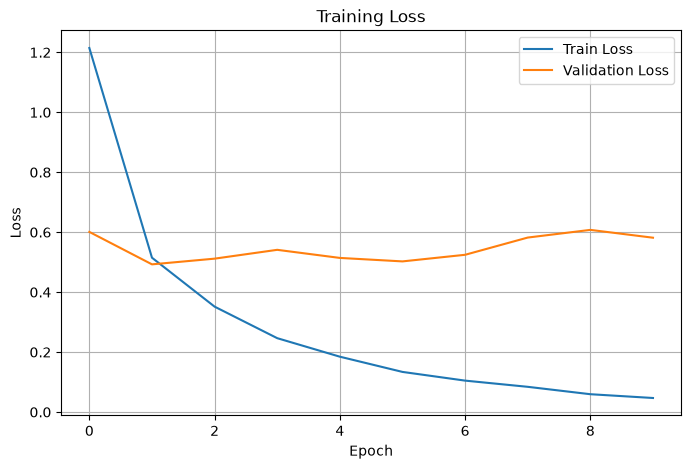

In [27]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True)
plt.show()

#### 12.02. Accuracy

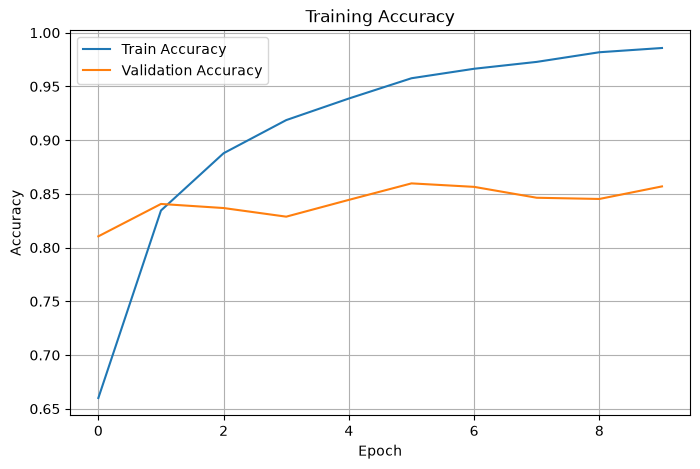

In [28]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()
plt.grid(True)
plt.show()

### 13. Summary

In [32]:
print('=' * 50)
print('TRAINING SUMMARY')
print('=' * 50)
print(f'Model               : ConvNeXt Tiny')
print(f'Number of classes   : {NUM_CLASSES}')
print(f'Epochs              : 10 (training stopped after the tenth epoch due to early signs of overfitting)')
print()
print(f'Training time       : {training_time/60:.2f} minutes')
print()
print(f'Saved model         : {best_model_path}')
print('=' * 50)

TRAINING SUMMARY
Model               : ConvNeXt Tiny
Number of classes   : 46
Epochs              : 10 (training stopped after the tenth epoch due to early signs of overfitting)

Training time       : 1330.96 minutes

Saved model         : best_convnext_tiny.pth


### 14. Conclusion

The baseline ConvNeXt Tiny model was successfully trained on the mushroom dataset.

Training was stopped after 10 epochs because the validation accuracy reached a plateau while the training accuracy continued to improve, indicating early signs of overfitting.

The best validation accuracy achieved during baseline training was approximately 86%.

The trained baseline model will be used as the starting point for the fine-tuning stage.